# 03b · Baseline predictors via Firth penalised logistic (brglm2)

Notebook 03 hit heavy separation (n=39, fitted probs 0/1) with plain `glm`. Here we use **Firth's bias-reduced logistic** (`brglm2`) which always produces finite estimates under separation and gives well-behaved CIs.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(broom); library(brglm2)
})
dat <- readRDS(file.path(OUT_OBJ, "baseline_and_delta.rds"))
cat("Analytic n:", nrow(dat), "\n")

Warning message:
“package ‘broom’ was built under R version 4.5.2”


Warning message:
“package ‘brglm2’ was built under R version 4.5.2”


Analytic n: 74 


In [2]:
base_vars <- c("age_at_visit","ageonset","duration_yrs","SEX","fampd","BMI",
               "LEDD","updrs3_score","NHY","NP1PAIN","NP1DPRS","NP1ANXS",
               "gds","stai","scopa")

run_uni_firth <- function(arm_label, subset) {
  purrr::map_dfr(base_vars, function(v) {
    sub <- subset[, c("no_worsening", v)] %>% tidyr::drop_na()
    if (nrow(sub) < 15 || dplyr::n_distinct(sub$no_worsening) < 2) {
      return(tibble::tibble(arm = arm_label, predictor = v, n = nrow(sub),
                            or = NA, lci = NA, uci = NA, p = NA))
    }
    fit <- tryCatch(
      stats::glm(stats::as.formula(paste("no_worsening ~", v)),
                 data = sub, family = "binomial",
                 method = brglm2::brglmFit),
      error = function(e) NULL)
    if (is.null(fit)) return(tibble::tibble(arm = arm_label, predictor = v, n = nrow(sub),
                                            or = NA, lci = NA, uci = NA, p = NA))
    co <- suppressMessages(broom::tidy(fit, conf.int = TRUE)) %>% dplyr::filter(term == v)
    tibble::tibble(arm = arm_label, predictor = v, n = nrow(sub),
                   or = exp(co$estimate), lci = exp(co$conf.low),
                   uci = exp(co$conf.high), p = co$p.value)
  })
}
uni_dbs   <- run_uni_firth("DBS",       dat %>% dplyr::filter(will_receive_dbs))
uni_nodbs <- run_uni_firth("Never-DBS", dat %>% dplyr::filter(!will_receive_dbs))
uni_all   <- run_uni_firth("Pooled",    dat)
uni <- dplyr::bind_rows(uni_dbs, uni_nodbs, uni_all)
print(uni, n = 60)
save_table(uni, "baseline_univariate_or_firth")

Warning message:
“The `tidy()` method for objects of class `brglmFit` is not maintained by the broom team, and is only supported through the `glm` tidier method. Please be cautious in interpreting and reporting broom output.

This warning is displayed once per session.”


# A tibble: 45 × 7
   arm       predictor        n    or    lci   uci      p
   <chr>     <chr>        <int> <dbl>  <dbl> <dbl>  <dbl>
 1 DBS       age_at_visit    40 1.03  0.942   1.12 0.556 
 2 DBS       ageonset        40 1.04  0.947   1.14 0.428 
 3 DBS       duration_yrs    40 1.06  0.524   2.13 0.879 
 4 DBS       SEX             40 0.556 0.0731  4.22 0.570 
 5 DBS       fampd           40 2.32  0.846   6.36 0.102 
 6 DBS       BMI             40 0.971 0.825   1.14 0.723 
 7 DBS       LEDD            40 1.000 0.998   1.00 0.787 
 8 DBS       updrs3_score    35 0.985 0.903   1.07 0.738 
 9 DBS       NHY             21 4.09  0.384  43.6  0.243 
10 DBS       NP1PAIN         40 0.700 0.351   1.40 0.311 
11 DBS       NP1DPRS         40 1.04  0.257   4.20 0.956 
12 DBS       NP1ANXS         40 0.890 0.315   2.51 0.825 
13 DBS       gds             24 0.953 0.652   1.39 0.802 
14 DBS       stai            24 0.980 0.924   1.04 0.506 
15 DBS       scopa           24 1.03  0.899   1.19 0.

In [3]:
dat_mv <- dat %>% dplyr::mutate(dbs = as.integer(will_receive_dbs)) %>%
  dplyr::select(no_worsening, dbs, age_at_visit, SEX, LEDD, updrs3_score, NP1PAIN, gds) %>%
  tidyr::drop_na()
cat("Multivariable n:", nrow(dat_mv), "\n")

f_main <- no_worsening ~ dbs + age_at_visit + SEX + LEDD + updrs3_score + NP1PAIN + gds
fit_main <- stats::glm(f_main, data = dat_mv, family = "binomial", method = brglm2::brglmFit)
out_main <- suppressMessages(broom::tidy(fit_main, conf.int = TRUE, exponentiate = TRUE))
print(out_main)
save_table(out_main, "mv_main_firth")

f_int <- no_worsening ~ dbs * (age_at_visit + LEDD + updrs3_score + NP1PAIN + gds) + SEX
fit_int <- stats::glm(f_int, data = dat_mv, family = "binomial", method = brglm2::brglmFit)
out_int <- suppressMessages(broom::tidy(fit_int, conf.int = TRUE, exponentiate = TRUE))
print(out_int)
save_table(out_int, "mv_interactions_firth")

Multivariable n: 39 


# A tibble: 8 × 7
  term         estimate std.error statistic p.value conf.low conf.high
  <chr>           <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 (Intercept)     1.11    3.09       0.0333  0.973   0.00259    474.  
2 dbs             2.86    0.949      1.11    0.268   0.446       18.4 
3 age_at_visit    1.04    0.0520     0.828   0.408   0.943        1.16
4 SEX             0.196   1.01      -1.61    0.107   0.0269       1.42
5 LEDD            1.01    0.00324    1.63    0.103   0.999        1.01
6 updrs3_score    0.967   0.0431    -0.768   0.443   0.889        1.05
7 NP1PAIN         1.17    0.387      0.411   0.681   0.549        2.50
8 gds             0.680   0.211     -1.83    0.0676  0.450        1.03


# A tibble: 13 × 7
   term             estimate std.error statistic p.value    conf.low  conf.high
   <chr>               <dbl>     <dbl>     <dbl>   <dbl>       <dbl>      <dbl>
 1 (Intercept)         5.21    6.53       0.253    0.801 0.0000144   1886997.  
 2 dbs                 1.74    7.82       0.0711   0.943 0.000000385 7904407.  
 3 age_at_visit        0.980   0.147     -0.138    0.891 0.734             1.31
 4 LEDD                1.01    0.00797    1.06     0.288 0.993             1.02
 5 updrs3_score        1.03    0.0888     0.278    0.781 0.861             1.22
 6 NP1PAIN             1.55    0.737      0.596    0.551 0.366             6.58
 7 gds                 0.843   0.355     -0.481    0.630 0.420             1.69
 8 SEX                 0.201   1.12      -1.43     0.153 0.0222            1.82
 9 dbs:age_at_visit    1.04    0.160      0.216    0.829 0.757             1.42
10 dbs:LEDD            0.992   0.00814   -1.02     0.306 0.976             1.01
11 dbs:updrs3_score  

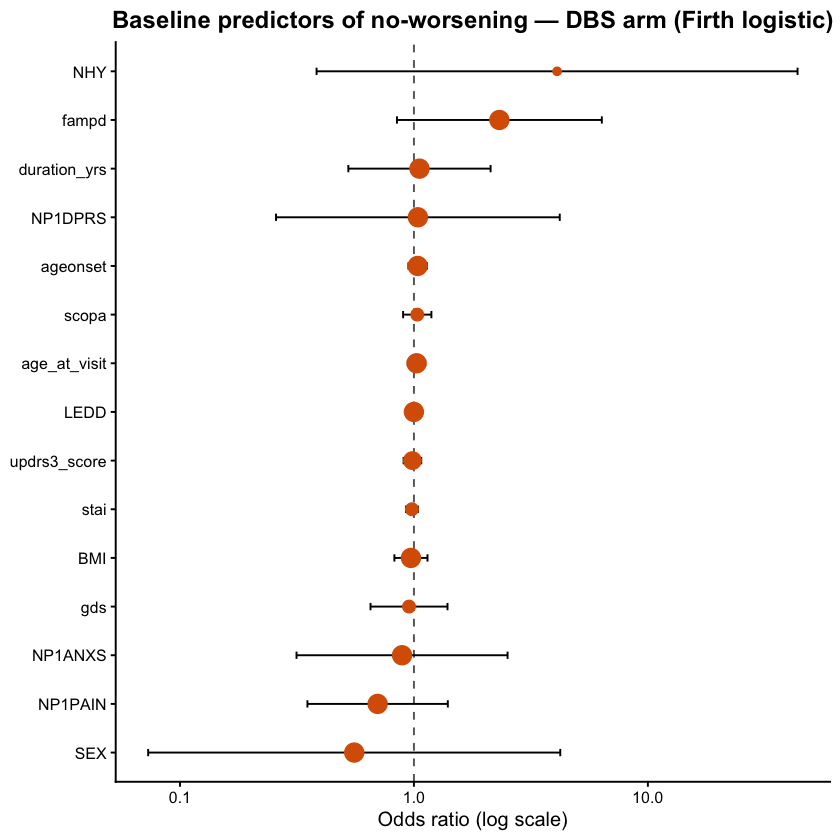

In [4]:
fp <- uni %>% dplyr::filter(arm == "DBS", !is.na(or), is.finite(or), or < 50) %>%
  dplyr::mutate(predictor = forcats::fct_reorder(predictor, or))
p_fp <- ggplot(fp, aes(x = or, y = predictor)) +
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(xmin = lci, xmax = uci), width = 0.15, orientation = "y") +
  geom_point(aes(size = n), colour = "#d95f02") +
  scale_x_log10() +
  scale_size_continuous(range = c(2, 5), guide = "none") +
  labs(title = "Baseline predictors of no-worsening — DBS arm (Firth logistic)",
       x = "Odds ratio (log scale)", y = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))
p_fp
save_fig(p_fp, "Fig10b_baseline_predictors_forest_DBS_firth", width = 7, height = 5)